# Prévision de la concentration en ozone

L'objectif, sur ces données, est d'améliorer la prévision déterministe (MOCAGE) de la concentration d'ozone calculée sur un maillage grossier de la terre par résolution des équations de Navier et Stokes car cette prévision est généralement biaisée. Il s'agit d'un problème d'adaptation statistique ou post-traitement d'une prévision locale par modèles à trop grande échelle en s'aidant d'autre variables également gérées par MétéoFrance, mais à plus petite échelle (température, force du vent...).

La question posée reste: quelle est la meilleure stratégie pour prévoir l'occurrence d'un pic de pollution.

## Prise en charge des données
Les données ont été extraites et mises en forme par le service concerné de Météo France. Elles sont décrites par les variables suivantes:

- JOUR Le type de jour ; férié (1) ou pas (0) ;
- O3obs La concentration d'ozone effectivement observée le lendemain à 17h locales correspondant souvent au maximum de pollution observée ;
- MOCAGE Prévision de cette pollution obtenue par un modèle déterministe de mécanique des fluides (équation de Navier et Stockes);
- TEMPE Température prévue par MétéoFrance pour le lendemain 17h ;
- RMH2O Rapport d'humidité ;
- NO2 Concentration en dioxyde d'azote ;
- NO Concentration en monoxyde d'azote ;
- STATION Lieu de l'observation : Aix-en-Provence, Rambouillet, Munchhausen, Cadarache et Plan de Cuques ;
- VentMOD Force du vent ;
- VentANG Orientation du vent.

In [52]:
import pandas as pd
import numpy as np
# Lecture des données présentes dans le dépôt
# path="./Data/"
# Lecture des données distantes sous Google Colab
path="https://www.math.univ-toulouse.fr/~besse/Wikistat/Data/"
ozone=pd.read_csv(path+"depSeuil.dat",sep=",",header=0)
# Vérification du contenu
ozone.head()

,JOUR,O3obs,MOCAGE,TEMPE,RMH2O,NO2,NO,STATION,VentMOD,VentANG
0,1,91,93.2,21.5,0.00847,1.602,0.424,Aix,9.5000,-0.64350
1,1,100,104.6,20.2,0.00881,2.121,0.531,Aix,8.0100,-0.04996
2,0,82,103.6,17.4,0.00951,1.657,0.467,Aix,9.3771,-0.12832
3,0,94,94.8,18.8,0.00855,2.350,0.701,Aix,9.4578,-0.34516
4,0,107,99.0,23.7,0.00731,1.653,0.452,Aix,7.8791,-0.41822


In [53]:
# informations sur les variables
ozone.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1041 entries, 0 to 1040
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   JOUR     1041 non-null   int64  
 1   O3obs    1041 non-null   int64  
 2   MOCAGE   1041 non-null   float64
 3   TEMPE    1041 non-null   float64
 4   RMH2O    1041 non-null   float64
 5   NO2      1041 non-null   float64
 6   NO       1041 non-null   float64
 7   STATION  1041 non-null   object 
 8   VentMOD  1041 non-null   float64
 9   VentANG  1041 non-null   float64
dtypes: float64(7), int64(2), object(1)
memory usage: 81.5+ KB


certaines types de colonnes sont mal organisés, donc il va falloir revoit le type de colonne

In [54]:
ozone['STATION']= pd.Categorical(ozone['STATION'], ordered=False)
ozone['JOUR']= pd.Categorical(ozone['JOUR'], ordered=False)
ozone['O3obs'] = pd.DataFrame(ozone['O3obs'], dtype=float)


In [55]:
ozone.dtypes

,0
JOUR,category
O3obs,float64
MOCAGE,float64
TEMPE,float64
RMH2O,float64
NO2,float64
NO,float64
STATION,category
VentMOD,float64
VentANG,float64


In [56]:
# description de ma base de donnée
ozone.describe()

,O3obs,MOCAGE,TEMPE,RMH2O,NO2,NO,VentMOD,VentANG
count,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000,1041.000000
mean,115.400576,127.219693,23.883381,0.010251,3.504645,0.657417,5.907186,0.163111
std,40.999155,39.820186,5.217462,0.003731,4.043308,0.844180,3.054307,0.708288
min,19.000000,46.400000,10.400000,0.002850,0.258000,0.001000,0.141420,-1.570790
25%,87.000000,97.500000,20.200000,0.007630,1.248000,0.236000,3.962320,-0.394790
50%,109.000000,125.600000,23.800000,0.009850,2.109000,0.388000,5.597300,0.278300
75%,135.000000,153.600000,27.600000,0.012440,4.062000,0.744000,7.106300,0.692640
max,319.000000,284.700000,38.000000,0.027530,44.396000,9.429000,19.891000,1.570790


## EDA

### Analyse univariée

In [57]:
# charger les librairies
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

Représenter les variables quantitatives

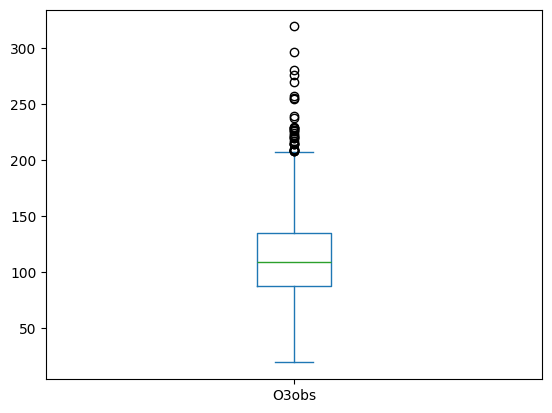

In [58]:
ozone['O3obs'].plot(kind='box')
plt.show()

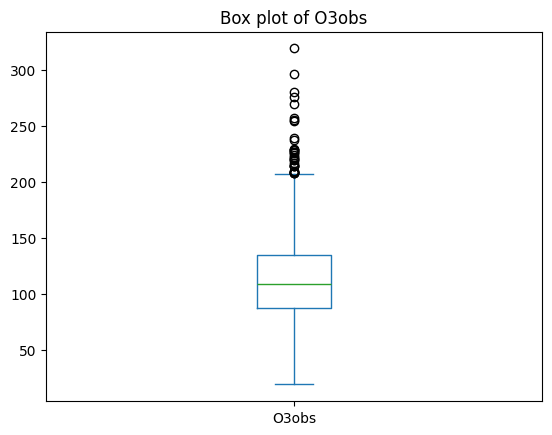

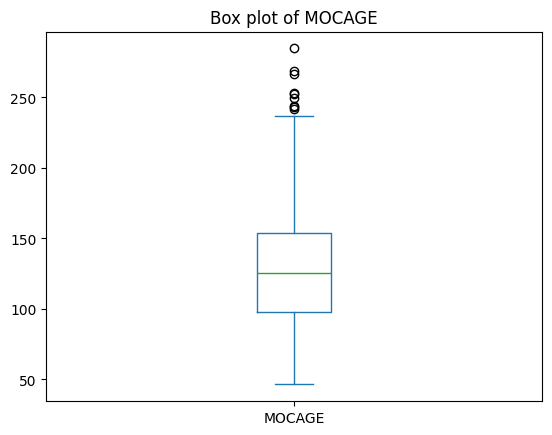

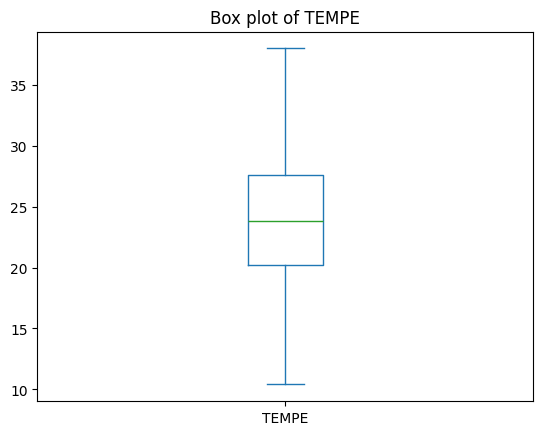

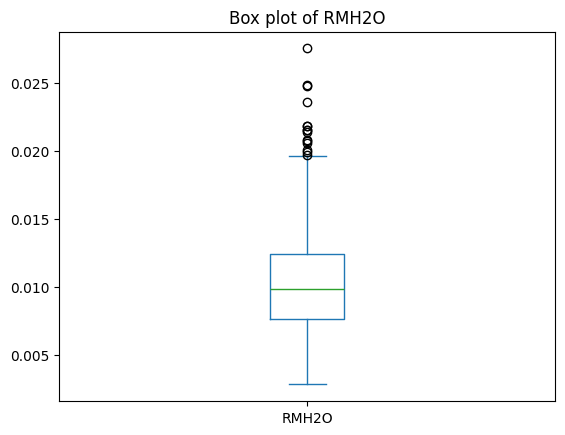

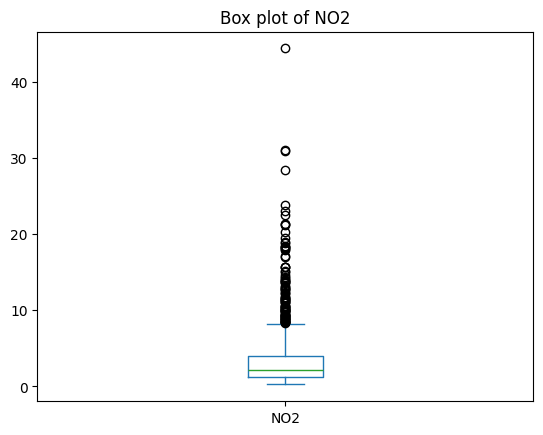

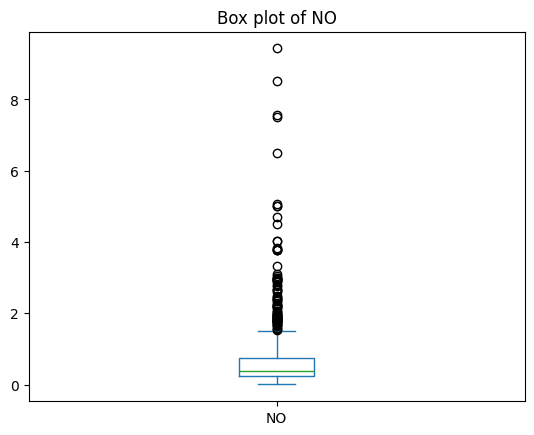

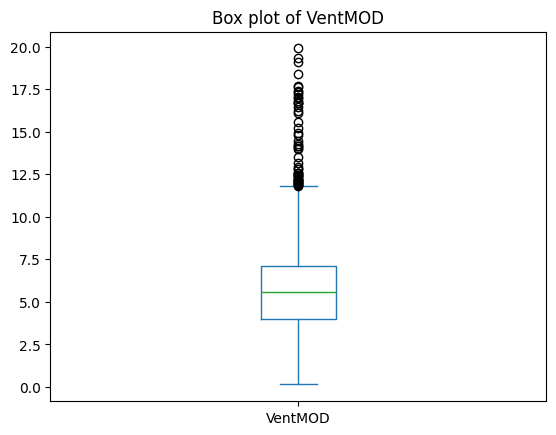

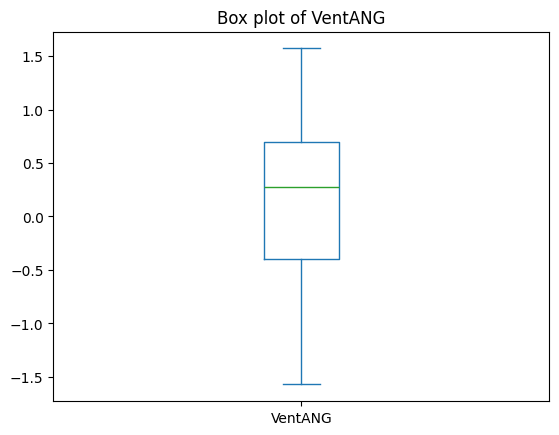

In [59]:
# tracer pour la majorité des variables quantitatives
for column in ozone.select_dtypes(include=np.number).columns:
    ozone[column].plot(kind='box')
    plt.title(f'Box plot of {column}')
    plt.show()

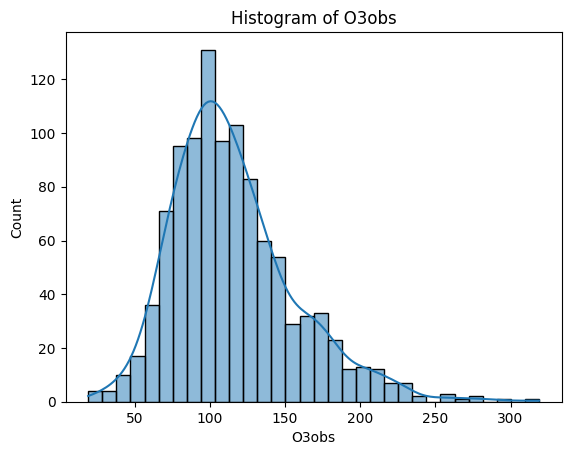

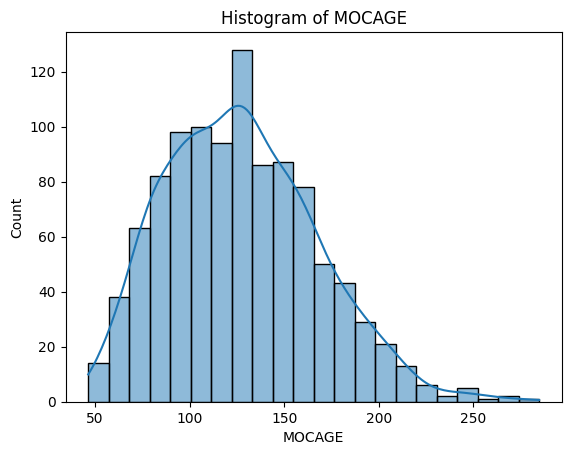

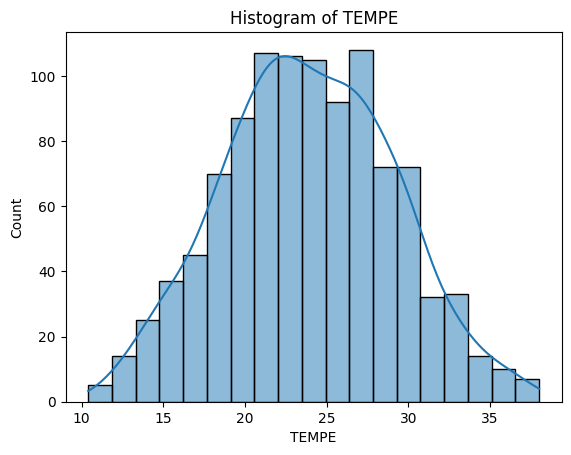

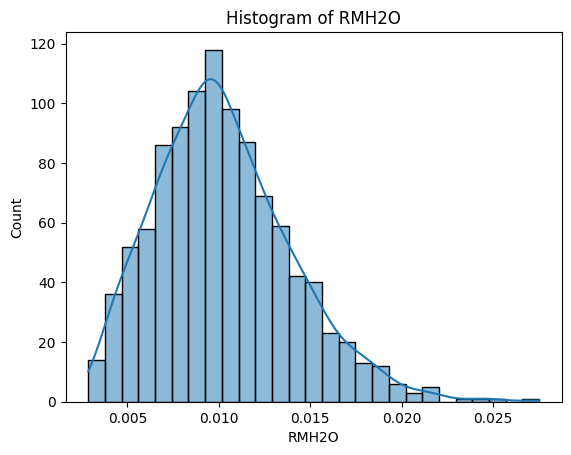

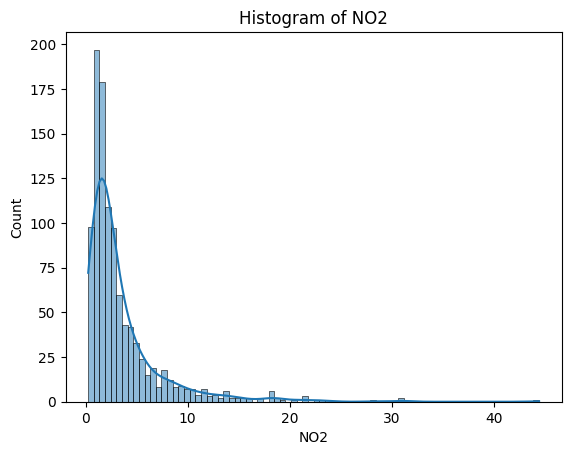

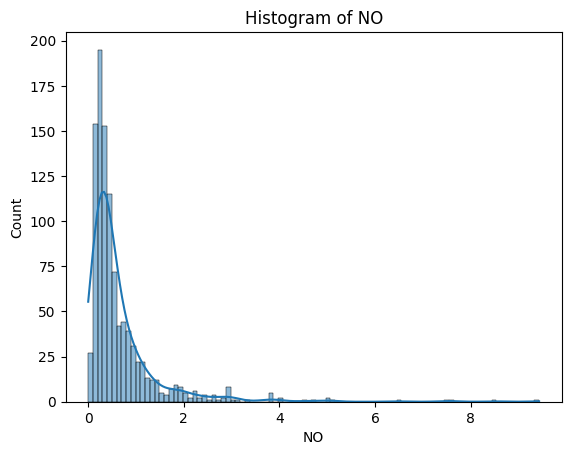

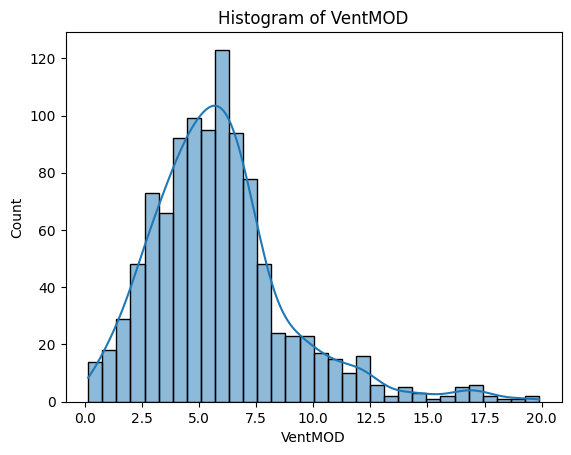

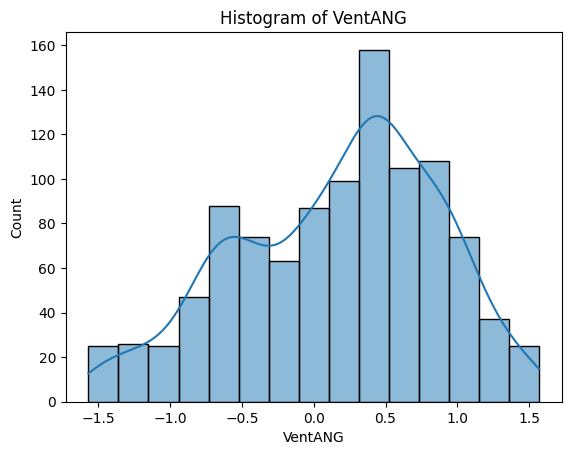

In [60]:
for column in ozone.select_dtypes(include=np.number).columns:
    sns.histplot(ozone[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.show()

On voit qu'il ya plusieurs graphiques qui ne suivent pas une distribution normale , donc il faut faire le feature engineering sur ces variables soit en les transformant ou en créant de nouvelles variables à partir des variables existantes.

#### Feature engineering

In [61]:
from math import sqrt, log
ozone['SRMH2O'] = ozone['RMH2O'].map(lambda x: sqrt(x))
ozone['LNO2'] = ozone['NO2'].map(lambda x: log(x))
ozone['LNO'] = ozone['NO'].map(lambda x: log(x))

# Supprimer les anciennes colonnes
del ozone['RMH2O']
del ozone['NO2']
del ozone['NO']

In [62]:
ozone.shape

(1041, 10)

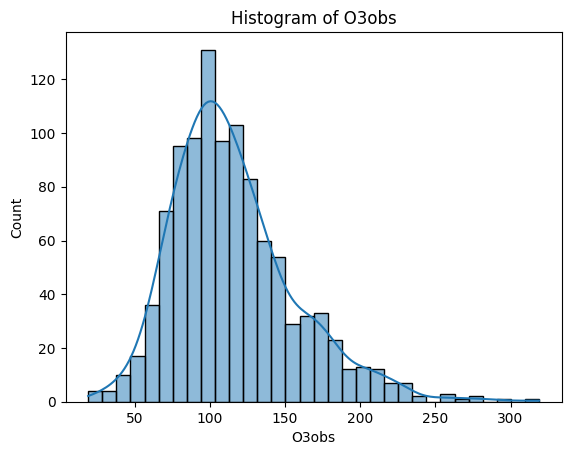

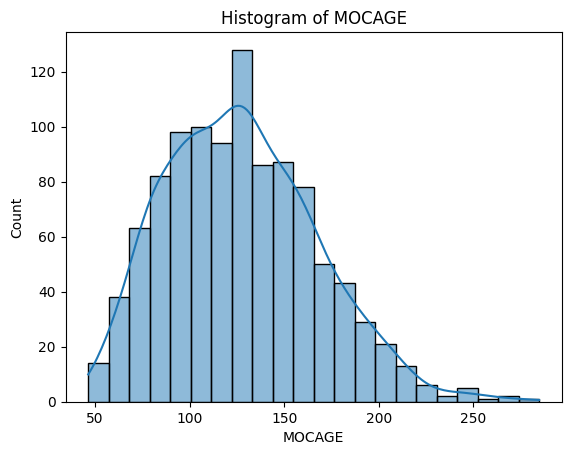

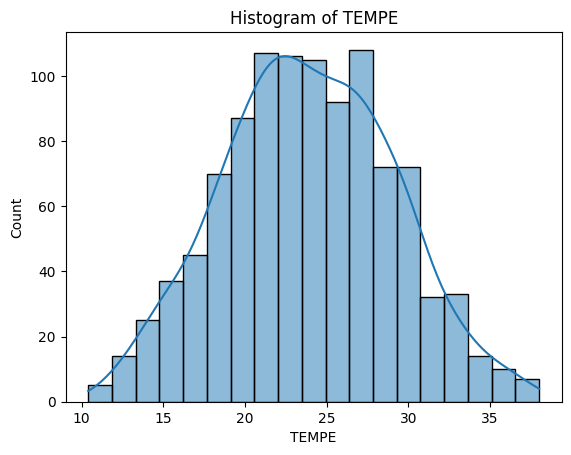

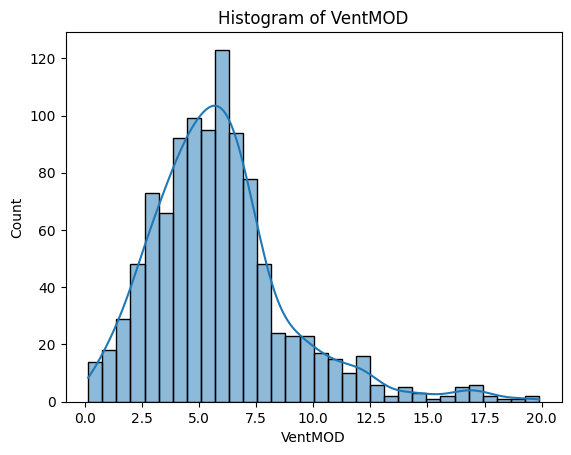

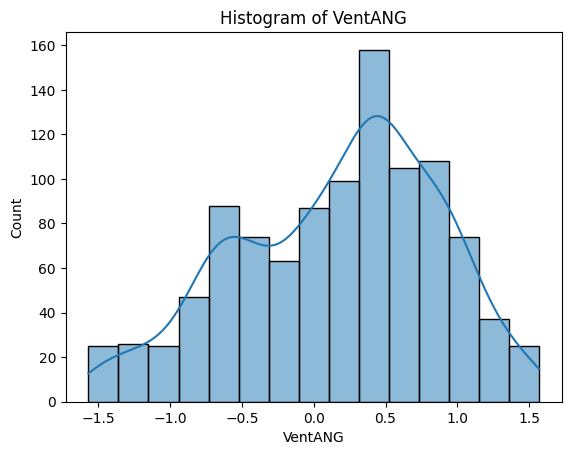

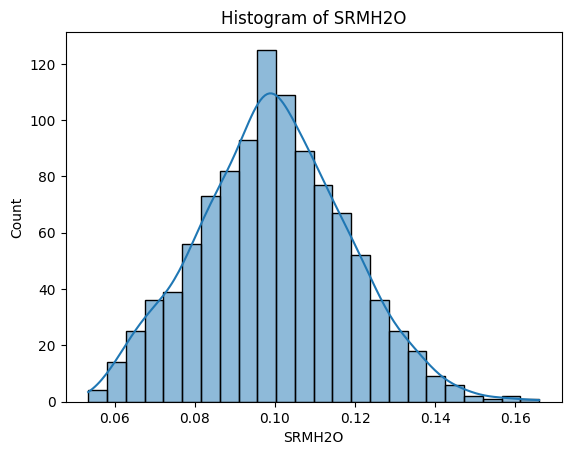

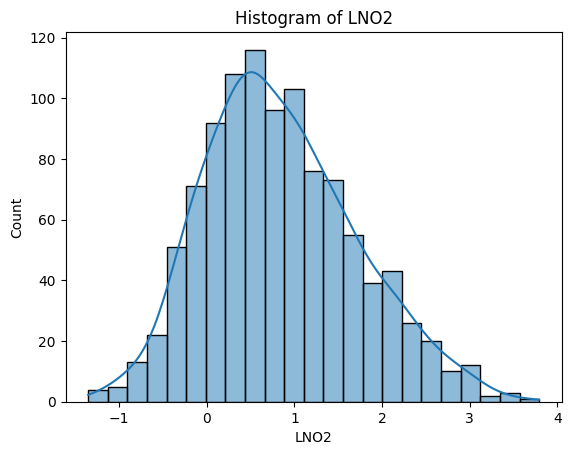

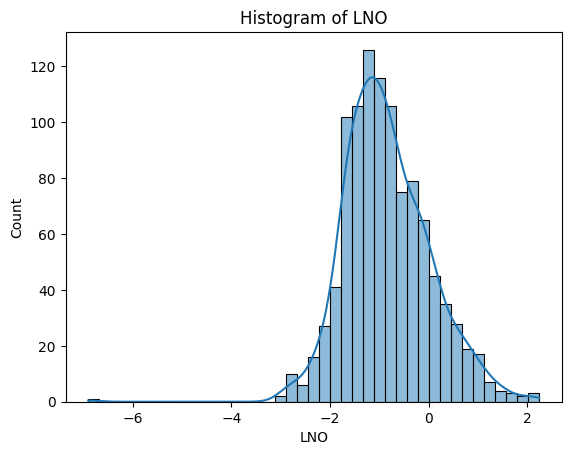

In [63]:
for column in ozone.select_dtypes(include=np.number).columns:
    sns.histplot(ozone[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.show()

Retirer les variables initiales et construire ci-dessous la variable "dépassement de seuil" pour obtenir le fichier qui sera effectivement utilisé.

In [64]:
ozone["DepSeuil"]=ozone["O3obs"].map(lambda x: x > 150)
ozone.head()

,JOUR,O3obs,MOCAGE,TEMPE,STATION,VentMOD,VentANG,SRMH2O,LNO2,LNO,DepSeuil
0,1,91.0,93.2,21.5,Aix,9.5000,-0.64350,0.092033,0.471253,-0.858022,False
1,1,100.0,104.6,20.2,Aix,8.0100,-0.04996,0.093862,0.751888,-0.632993,False
2,0,82.0,103.6,17.4,Aix,9.3771,-0.12832,0.097519,0.505009,-0.761426,False
3,0,94.0,94.8,18.8,Aix,9.4578,-0.34516,0.092466,0.854415,-0.355247,False
4,0,107.0,99.0,23.7,Aix,7.8791,-0.41822,0.085499,0.502592,-0.794073,False


Une variable qualitative
Pour une variable qualitative, il est important d'identifier des modalités à trop faible effectif ou encore des effectifs très déséquilibrés. Des regroupements peuvent alors être opérés entre les modalatés.

In [65]:
for column in ozone.select_dtypes(include='category').columns:
    print(f"Value counts for {column}:")
    print(ozone[column].value_counts())
    print("\n")

Value counts for JOUR:
JOUR
0    724
1    317
Name: count, dtype: int64


Value counts for STATION:
STATION
Als    222
Ram    210
Pla    208
Cad    202
Aix    199
Name: count, dtype: int64




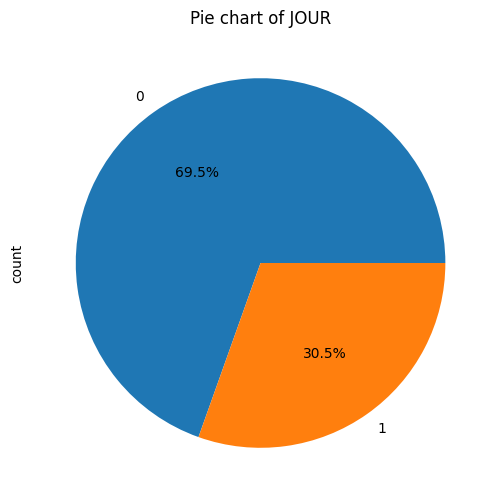

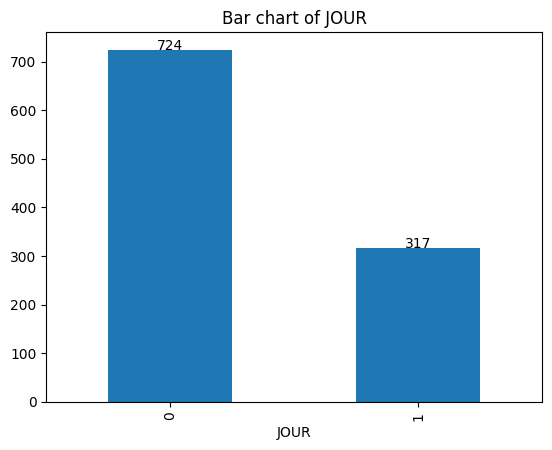

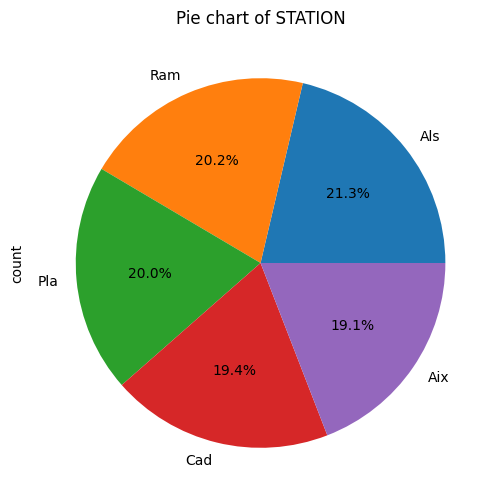

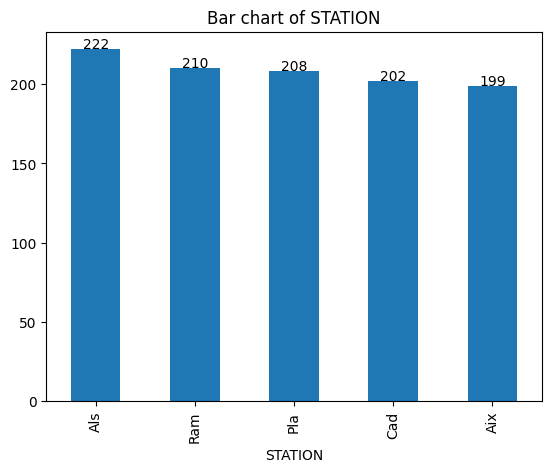

In [66]:
# générer le pie chart et le barplot
for column in ozone.select_dtypes(include='category').columns:
    # Pie chart
    ozone[column].value_counts().plot(kind='pie', autopct ='%1.1f%%', figsize=(6, 6))
    plt.title(f'Pie chart of {column}')
    plt.show()

    # Bar plot
    counts = ozone[column].value_counts()
    ax_bar = counts.plot(kind='bar')
    plt.title(f'Bar chart of {column}') # Changed title to 'Bar chart'
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(counts):
        ax_bar.text(i, v + 0.5, str(v), ha='center')

    plt.show()

### Analyse bivariée

Deux variables quantitatives

La liaison entre deux variables quantitatives est quantifiée par le coefficient de corrélation linéaire (Bravey Pearson) mais cet indicateur numérique est trop partiel; il ne prend en compte qu'un possible liaison linéaire entre deux variables. Un graphique est très utile pour préciser la nature de la liaison.

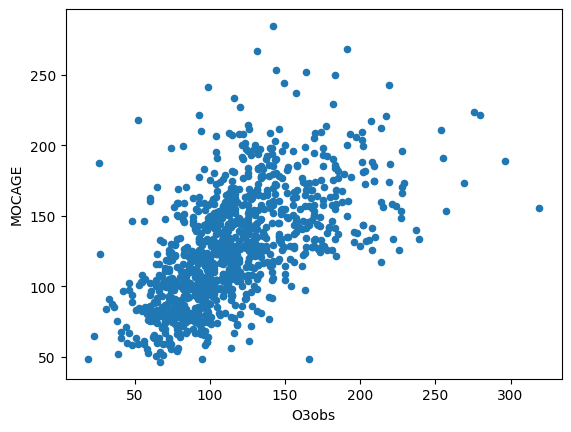

In [67]:
ozone.plot(kind="scatter",x="O3obs",y="MOCAGE")
plt.show()

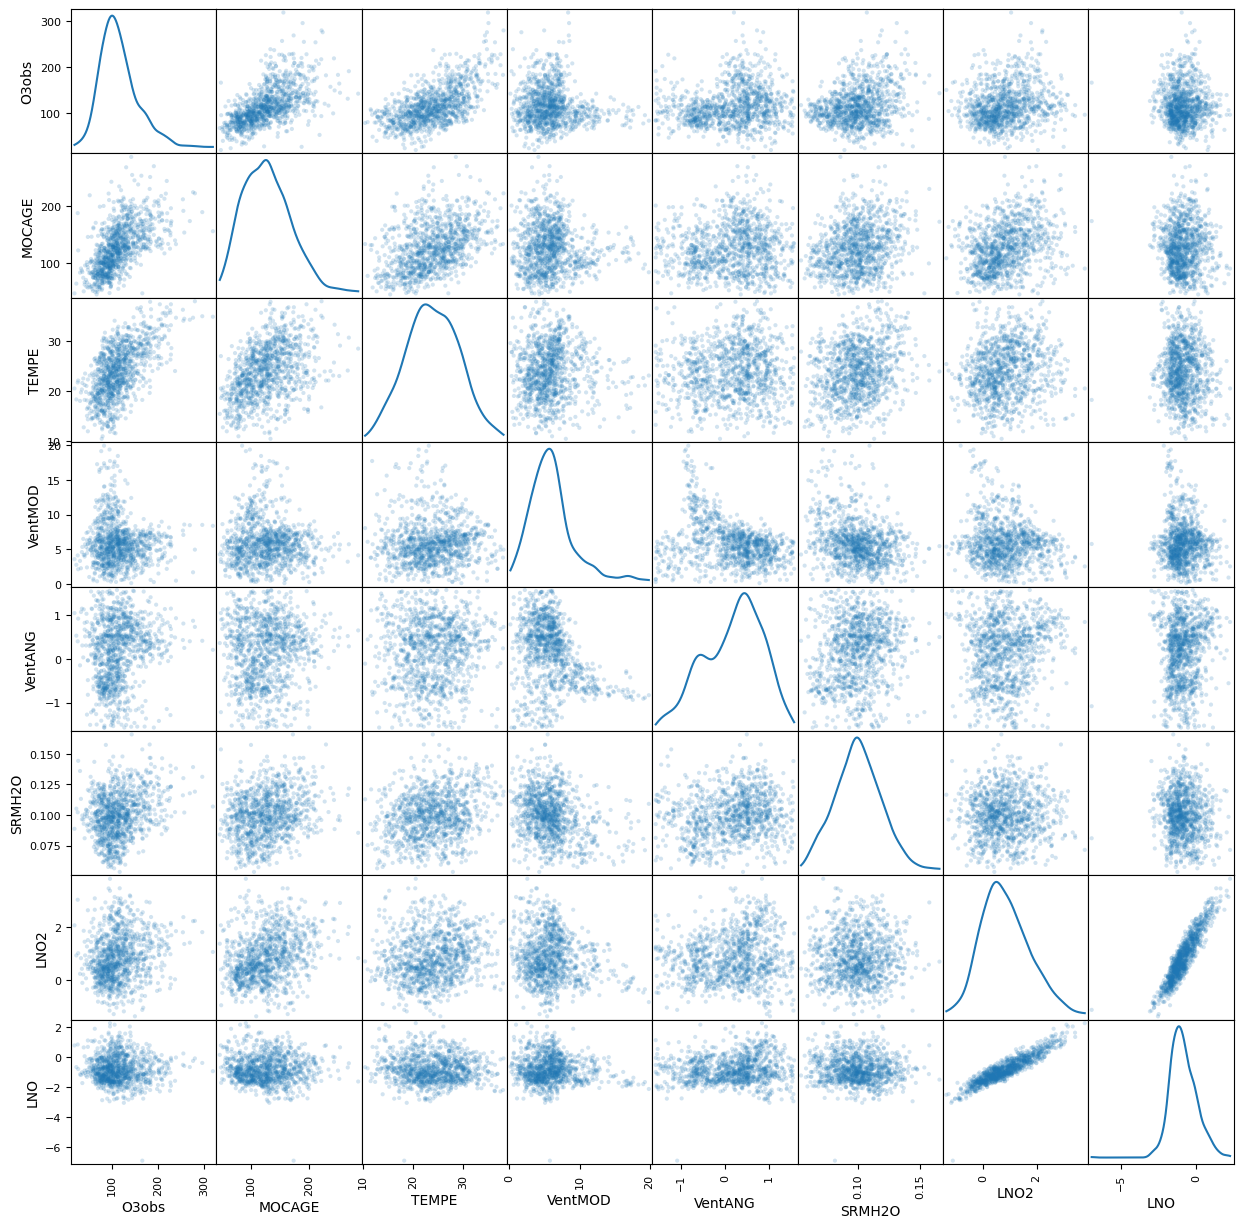

In [68]:
from pandas.plotting import scatter_matrix
scatter_matrix(ozone[["O3obs","MOCAGE","TEMPE","VentMOD","VentANG","SRMH2O","LNO2","LNO"]], alpha=0.2, figsize=(15, 15), diagonal='kde')
plt.show()

Graphiques diagonaux (KDE - Kernel Density Estimate) :

Ces courbes de densité montrent la distribution de chaque variable individuelle. Par exemple, la distribution de O3obs et MOCAGE nous permet de voir leur forme (normale, asymétrique, multimodale) et d'identifier les valeurs les plus fréquentes. Une distribution normale est généralement souhaitable pour de nombreux modèles statistiques, tandis que l'asymétrie peut indiquer la présence de valeurs extrêmes ou un besoin de transformation des données.
Graphiques hors diagonale (nuages de points) :

Ces graphiques affichent les relations entre chaque paire de variables. Ils nous permettent d'inspecter visuellement ces relations :
- O3obs vs. MOCAGE : Il est essentiel d'examiner la corrélation entre la prévision (MOCAGE) et l'observation (O3obs). Idéalement, nous devrions observer une forte corrélation linéaire positive, où les points s'alignent étroitement le long d'une droite ascendante. Si la plupart des points sont proches de cette ligne, cela signifie que MOCAGE est un bon prédicteur de O3obs. Tout écart systématique par rapport à cette ligne pourrait indiquer un biais dans le modèle MOCAGE (par exemple, surestimation ou sous-estimation constante).
- O3obs vs. TEMPE : Il est courant de voir une corrélation positive entre la température (TEMPE) et la concentration d'ozone (O3obs), car des températures plus élevées favorisent les réactions chimiques qui produisent l'ozone. Le nuage de points peut confirmer cette tendance et montrer la force de cette relation.
- O3obs vs. SRMH2O (Racine Carrée de RMH2O) : L'humidité peut influencer la chimie de l'ozone. Le graphique peut révéler si cette influence est linéaire, non linéaire ou faible.
- O3obs vs. LNO2 (Log de NO2) et LNO (Log de NO) : Les oxydes d'azote (NOx) sont des précurseurs clés de l'ozone, mais ils peuvent aussi le détruire. Les relations avec leurs versions log-transformées peuvent être complexes, montrant parfois un pic d'ozone à des niveaux intermédiaires de NOx, puis une diminution à des niveaux très élevés (phénomène de titration).
- O3obs vs. VentMOD (Force du vent) et VentANG (Orientation du vent) : Le vent joue un rôle crucial dans la dispersion des polluants. Une vitesse de vent élevée pourrait être corrélée à des niveaux d'ozone plus faibles en raison de la dilution, tandis que l'orientation du vent pourrait indiquer l'origine des masses d'air polluées.
En résumé, cette matrice nous permet d'identifier rapidement :

- Tendances et corrélations : Si les variables se déplacent ensemble (corrélation positive), dans des directions opposées (corrélation négative) ou si elles sont indépendantes.
- Formes des relations : Si elles sont linéaires, curvilignes ou plus complexes.
Outliers : Des points de données qui s'écartent significativement du comportement général.
- Distribution des variables : Grâce aux graphiques de densité sur la diagonale.

*Une variable quantitative et une qualitative*
***
L'indicateur quantitatif de liaison entreces deux types de variable est le rapport de corrélation: la racine carrée du rapport de la variance expliquée par la partition sur la variance totale. Il n'est pas calculé au profit d'un graphique comparant les distributions pour les deux classes ou modalités de la variable qualitative.

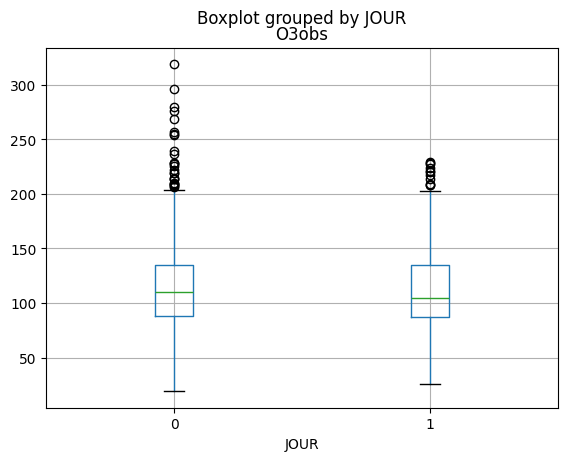

In [69]:
ozone.boxplot(column="O3obs",by="JOUR")
plt.show()

Deux variables qualitatives
Un test dit du khi2 permettrait de tester l'hypothèse Ho: les variables sont indépendantes. Nous nous contenterons d'un graphique permettant de représenter la possible liaison entre deux variables qualitatives.

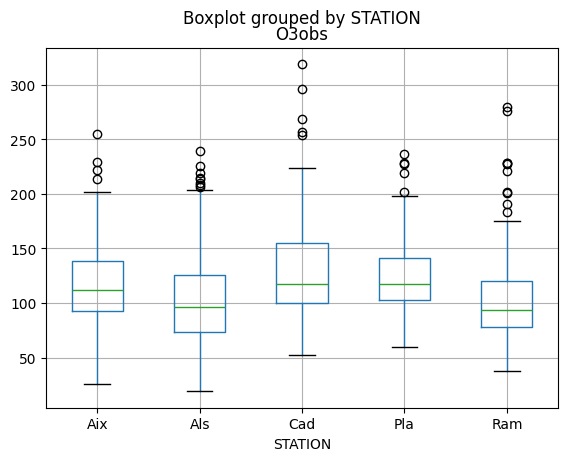

In [70]:
ozone.boxplot(column="O3obs",by="STATION")
plt.show()

In [71]:
# creer un tableau de contingence
table=pd.crosstab(ozone["DepSeuil"],ozone["STATION"])
print(table)

STATION   Aix  Als  Cad  Pla  Ram
DepSeuil                         
False     162  192  149  172  188
True       37   30   53   36   22


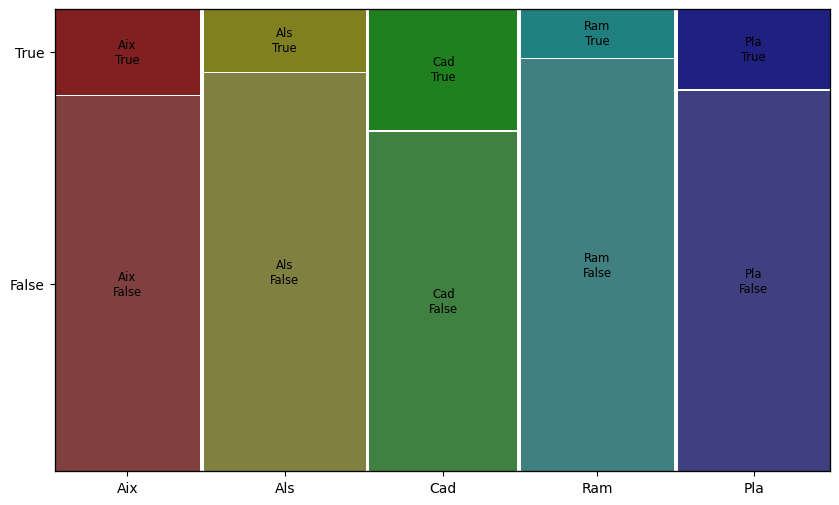

In [72]:
from statsmodels.graphics.mosaicplot import mosaic
# modifier la taille du graphique
fig, ax = plt.subplots(figsize=(10,6))
mosaic(ozone,["STATION", "DepSeuil"], ax=ax)
plt.show()

# Mise en place de l'ACP

  ***Principe*** :

- Elle recherche les axes de plus grande dispersion du nuages des individus dans Rp avec p=8. Ces axes sont définis par les vecteurs propres de la matrice des covariances ou des corrélations si les variables sont réduites (divisées par l'écart-type).

- Les représentations graphiques des individus sont obtenues par projection sur les sous-espaces engendrés par les premiers vecteurs propres. Elles préservent au mieux les distances entre ceux-ci.
- Les coordonnées sont stockées dans la matrice des composantes principales qui sont aussi les combinaisons linéaires de plus grande variance des variables. Ce sont des variables décorrélées, orthogonales deux à deux.

- Les representations graphiques des variables initiales conservent au mieux les angles entre les vecteurs variables dans l'espace Rn de façon à interpréter leurs corrélations qui, géométriquement, sont les cosinus de ces angles.

In [73]:
# installation des packages necessaires
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale
# reduction de la variable
x = scale(ozone[["O3obs","MOCAGE","TEMPE","VentMOD","VentANG","SRMH2O","LNO2","LNO"]])

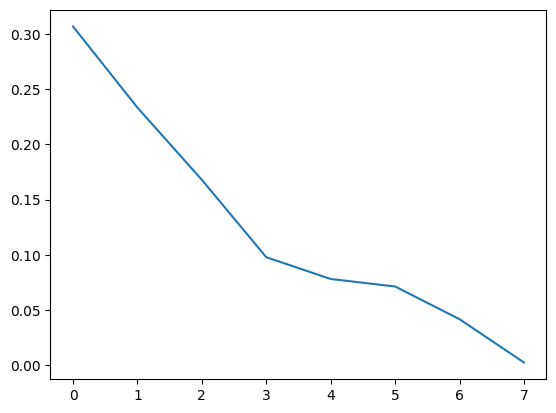

In [74]:
pca = PCA()
# estimation et calcul des composantes principales
c = pca.fit(x).transform(x)
# décroissance de la variable expliquée
plt.plot(pca.explained_variance_ratio_)
plt.show()

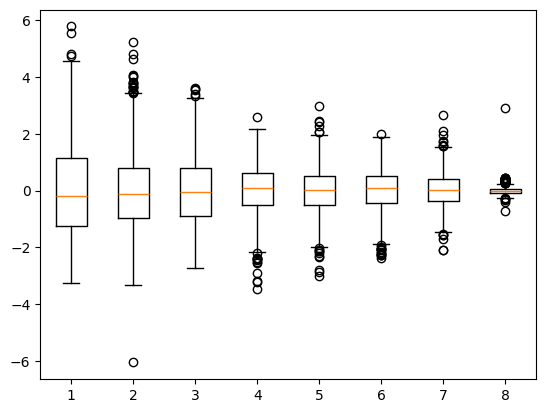

In [75]:
# distribution des composantes principales
plt.boxplot(c)
plt.show()

Ce graphique nous montre que notre jeu de donnée contient des potentiels outliers. Donc il va falloir traiter ces données.

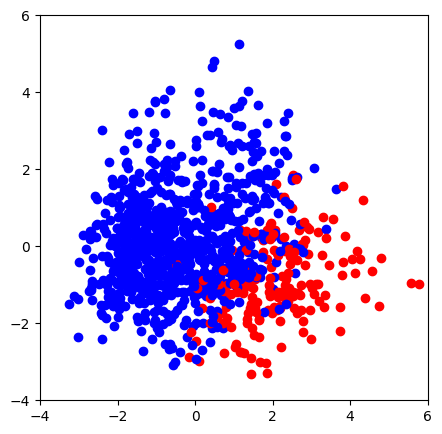

In [76]:
## Repésentation des individus
plt.figure(figsize=(5,5))
for i, j, nom in zip(c[:,0], c[:,1], ozone["DepSeuil"]):
    color = "red" if nom  else "blue"
    plt.plot(i, j, "o",color=color)
plt.axis((-4,6,-4,6))
plt.show()

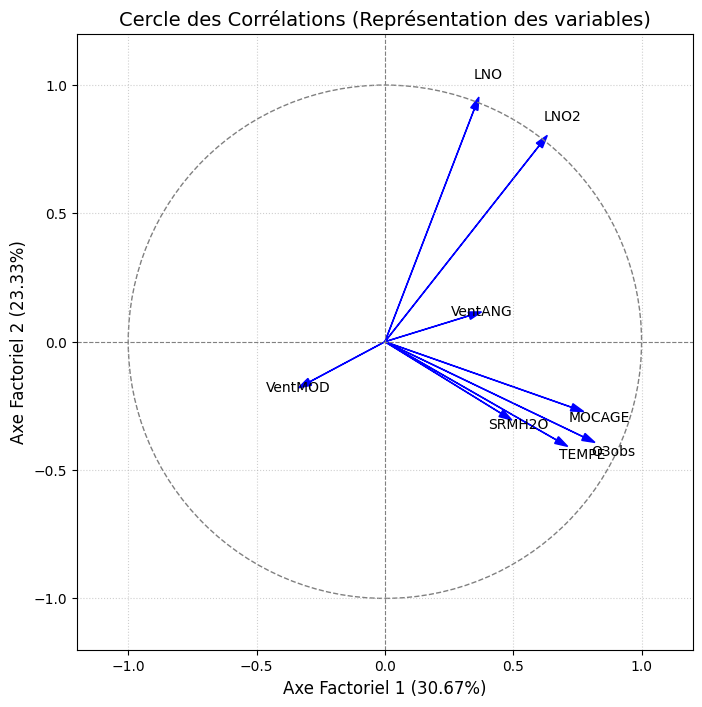

In [77]:
# Re-calculating coordinates and plotting variables for clarity and emphasis on factorial axes
# Ensure necessary libraries and variables (pca, ozone, np, plt) are available from previous cells.

# Define the features used for PCA
features_for_pca = ["O3obs","MOCAGE","TEMPE","VentMOD","VentANG","SRMH2O","LNO2","LNO"]

# Coordonnées des variables sur les axes factoriels (corrélations des variables avec les composantes principales)
coord1_vars = pca.components_[0] * np.sqrt(pca.explained_variance_[0])
coord2_vars = pca.components_[1] * np.sqrt(pca.explained_variance_[1])

fig, ax = plt.subplots(figsize=(12,8))

# Plotting arrows for variables
for i, (x_coord, y_coord, var_name) in enumerate(zip(coord1_vars, coord2_vars, features_for_pca)):
    ax.arrow(0, 0, x_coord, y_coord, head_width=0.03, head_length=0.05, fc='blue', ec='blue')
    ax.text(x_coord * 1.15, y_coord * 1.15, var_name, color='black', ha='center', va='center', fontsize=10)

# Add the circle of correlations
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--')
ax.add_patch(circle)

# Add horizontal and vertical lines for axes
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)

# Set axis limits
ax.set_xlim([-1.2, 1.2])
ax.set_ylim([-1.2, 1.2])

# Add labels for factorial axes with explained variance
explained_variance_ratio_pc1 = pca.explained_variance_ratio_[0] * 100
explained_variance_ratio_pc2 = pca.explained_variance_ratio_[1] * 100
ax.set_xlabel(f'Axe Factoriel 1 ({explained_variance_ratio_pc1:.2f}%)', fontsize=12)
ax.set_ylabel(f'Axe Factoriel 2 ({explained_variance_ratio_pc2:.2f}%)', fontsize=12)
ax.set_title('Cercle des Corrélations (Représentation des variables)', fontsize=14)
ax.set_aspect('equal', adjustable='box') # Ensures the circle is round
ax.grid(True, linestyle=':', alpha=0.6)

plt.show()

***Interprétation spécifique de votre graphique:***

***
* Fortes corrélations positives avec l'Axe 1 : Vous pouvez observer que O3obs, MOCAGE, TEMPE, LNO2, et SRMH2O sont fortement projetées positivement sur l'Axe 1. Cela signifie que ces variables sont fortement corrélées positivement entre elles et que l'Axe 1 capture une dimension où ces variables varient ensemble. Une augmentation de l'ozone observé ou prédit est souvent associée à une augmentation de la température et à des niveaux de NO2 et d'humidité spécifiques.
Faible corrélation avec l'Axe 2 pour ces variables : Ces mêmes variables sont relativement proches de l'axe horizontal, indiquant une corrélation plus faible avec l'Axe 2.

* Variables associées à l'Axe 2 : VentMOD et VentANG semblent avoir une certaine projection sur l'Axe 2, suggérant que cet axe capture des informations liées aux conditions du vent, et qu'elles sont moins corrélées avec l'Axe 1.

* Relations entre variables : O3obs, MOCAGE, TEMPE sont très proches les unes des autres et fortement corrélées. LNO est orienté de manière quasi opposée à O3obs, MOCAGE et TEMPE sur l'Axe 1, ce qui suggère une corrélation négative avec ces variables sur cette dimension.
En résumé, l'Axe 1 semble être principalement une dimension liée à la concentration d'ozone et aux conditions météorologiques et chimiques qui lui sont associées, tandis que l'Axe 2 pourrait être lié aux variables de vent. Les variables O3obs, MOCAGE, et TEMPE sont très bien représentées par les premiers axes, ce qui signifie que le plan factoriel 1-2 est très pertinent pour les analyser.

# Mise en place de l'AFD

L'AFD est l'ACP des barycentres des classes avec la métrique de Mahalanobis dans l'espace des individus.

Les données sont sont obtenues par l'observation de 6 variables, des dimensions d'ailes, élitres, antennes, pattes de 3 classes d'insectes. Il s'agit donc de vérifier graphiquement la bonne capacité de ces variables à distinguer ou discriminer ces trois classes.

## chargement des données

In [78]:
insect=pd.read_table("https://www.math.univ-toulouse.fr/~besse/Wikistat/Data/lubisch.txt",sep='\s+',header=0)
insect

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1930390597.py:1: SyntaxWarning: invalid escape sequence '\s'
  insect=pd.read_table("https://www.math.univ-toulouse.fr/~besse/Wikistat/Data/lubisch.txt",sep='\s+',header=0)


,X1,X2,X3,X4,X5,X6,Y
0,191.0,131.0,53.0,150.0,15.0,104.0,b
1,185.0,134.0,50.0,147.0,13.0,105.0,b
2,200.0,137.0,52.0,144.0,14.0,102.0,b
3,173.0,127.0,50.0,144.0,16.0,97.0,b
4,171.0,118.0,49.0,153.0,13.0,106.0,b
...,...,...,...,...,...,...,...
69,187.0,120.0,47.0,121.0,15.0,86.0,r
70,210.0,119.0,50.0,128.0,14.0,68.0,r
71,196.0,114.0,51.0,129.0,14.0,86.0,r
72,195.0,110.0,49.0,124.0,13.0,89.0,r


## ACP

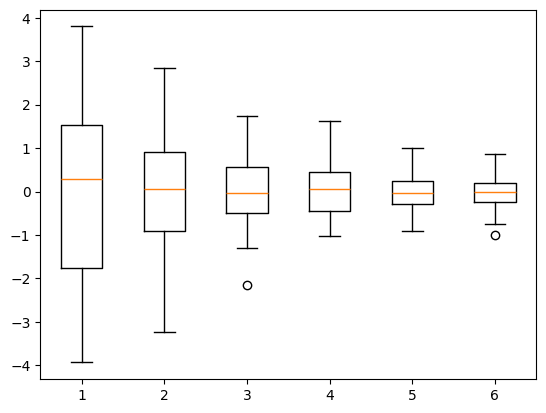

In [79]:
from sklearn.preprocessing import scale
X=scale(insect[["X1","X2","X3","X4","X5","X6"]])
Y=insect["Y"]
C = pca.fit(X).transform(X)
plt.boxplot(C)
plt.show()

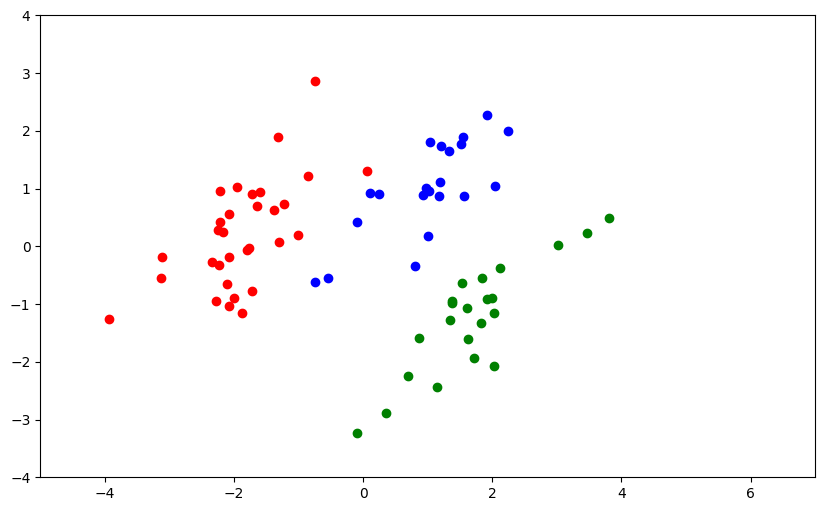

In [80]:
plt.figure(figsize=(10,6))
for i, j, nom in zip(C[:,0],C[:,1], Y):
    plt.scatter(i, j, color=nom)
plt.axis((-5,7,-4,4))
plt.show()

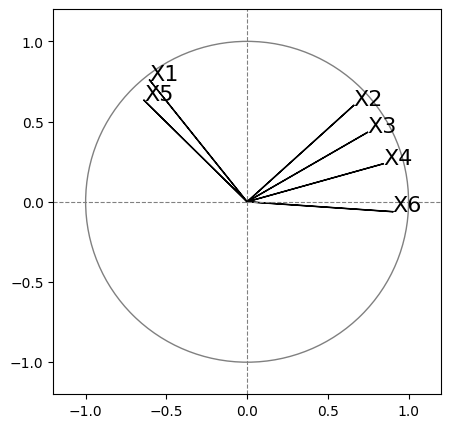

In [81]:
coord1=pca.components_[0]*np.sqrt(pca.explained_variance_[0])
coord2=pca.components_[1]*np.sqrt(pca.explained_variance_[1])
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(1, 1, 1)
for i, j, nom in zip(coord1,coord2, insect.columns):
    plt.text(i, j, nom, fontsize=16)
    plt.arrow(0,0,i,j,color='black')
# Add horizontal and vertical lines for axes
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)


plt.axis((-1.2,1.2,-1.2,1.2))
# cercle
c=plt.Circle((0,0), radius=1, color='gray', fill=False)
ax.add_patch(c)
plt.show()

## AFD

In [85]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
method = LinearDiscriminantAnalysis()
lda = method.fit(X,Y)

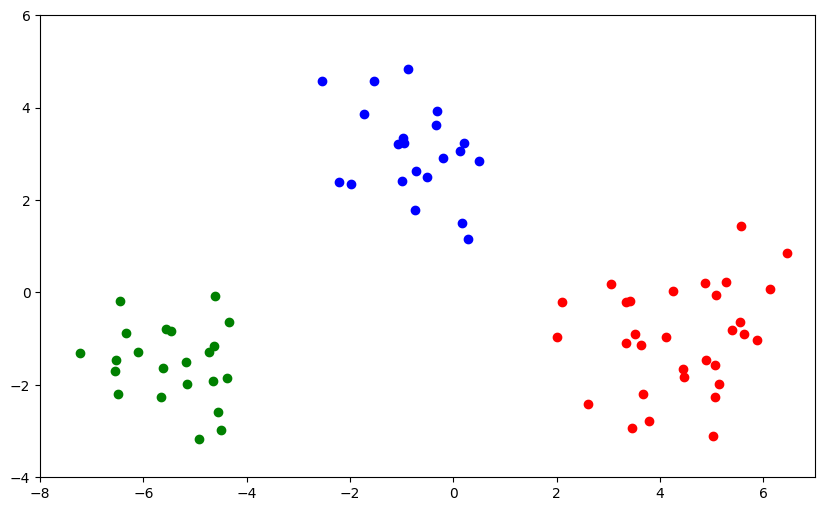

In [84]:
Clda=lda.transform(X)
plt.figure(figsize=(10,6))
for i, j, nom in zip(Clda[:,0],Clda[:,1], Y):
    plt.scatter(i, j, color=nom)
plt.axis((-8,7,-4,6))
plt.show()

Chaque couleur représente une des trois classes d'insectes ('b', 'g', 'r').

Séparation des classes : L'observation la plus frappante est l'excellente séparation des trois classes d'insectes. Les points de couleur bleue ('b'), verte ('g') et rouge ('r') forment des groupes très distincts et bien isolés les uns des autres. Il y a très peu, voire pas du tout, de chevauchement entre les classes.

Rôle des axes discriminants :

* Premier axe discriminant (horizontal) : Cet axe semble être le plus efficace pour séparer les classes. On voit clairement que la classe 'b' est principalement regroupée à gauche de cet axe, tandis que les classes 'g' et 'r' sont positionnées plus à droite, avec 'r' tendant vers l'extrême droite. Cela indique que cette première fonction discriminante capture la majorité de l'information qui distingue ces groupes.

* Deuxième axe discriminant (vertical) : Bien que le premier axe soit dominant, le deuxième axe contribue également à la séparation, notamment en différenciant davantage la classe 'g' des classes 'b' et 'r' sur la dimension verticale, et en aidant à affiner la séparation entre 'g' et 'r'.
Conclusion:

Ce graphique AFD démontre que les 6 utilisées (X1 à X6) sont extrêmement discriminantes. Elles permettent de distinguer très clairement les trois espèces d'insectes. En d'autres termes, les caractéristiques mesurées (dimensions des ailes, élytres, antennes, pattes) sont de très bons indicateurs pour classer ces insectes dans leurs catégories respectives.